#Kavish Nag
#24070126085
#AIML B1

In [591]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.preprocessing import StandardScaler

In [592]:
df = sns.load_dataset("mpg")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [593]:
#take all columns except the selling_price
df.dropna(inplace=True)
X=df.drop(['mpg','name','origin'],axis=1)
y = df['mpg']
print(X.shape)
print(y.shape)

(392, 6)
(392,)


In [594]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#LINEAR

In [595]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [596]:
print("Intercept: ", model.intercept_)
print("Coefficients: ")
list(zip(x_train, model.coef_))

Intercept:  -15.057758585282361
Coefficients: 


[('cylinders', np.float64(-0.11617299975151561)),
 ('displacement', np.float64(0.0010134737992773786)),
 ('horsepower', np.float64(-0.002276343551502179)),
 ('weight', np.float64(-0.006561006002989316)),
 ('acceleration', np.float64(0.0617355075324829)),
 ('model_year', np.float64(0.7606364443382331))]

In [597]:
y_pred=model.predict(x_test)

In [598]:
from sklearn.metrics import r2_score
r2_score_multi= r2_score(y_test,y_pred)
r2_score_multi

0.7942349075428586

In [599]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mse


10.502370329417325

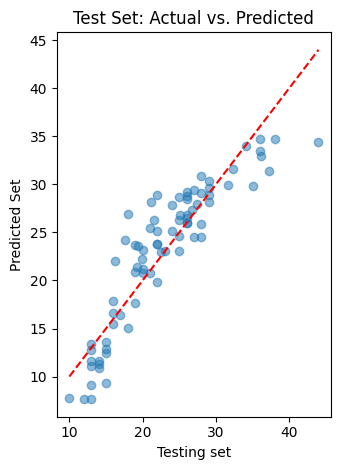

In [600]:
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Testing set')
plt.ylabel('Predicted Set')
plt.title('Test Set: Actual vs. Predicted')

plt.tight_layout()
plt.show()

#POLYNOMIAL

In [601]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x_train)

In [602]:
model_poly = LinearRegression()
model_poly.fit(x_poly, y_train)

x_test_poly = poly.transform(x_test)
y_pred = model_poly.predict(x_test_poly)

In [603]:
from sklearn.metrics import r2_score
r2_score_poly= r2_score(y_test,y_pred)

In [604]:
mse_poly = mean_squared_error(y_test,y_pred)

#RIDGE


In [605]:
ridge_model = Ridge(alpha = 10)
ridge_model.fit(x_poly,y_train)
y_pred = ridge_model.predict(x_test_poly)

In [606]:
r2_score_ridge = r2_score(y_test,y_pred)
r2_score_ridge

0.8486976240105301

In [607]:
mse_ridge=mean_squared_error(y_test,y_pred)

#LASSO


In [608]:
lasso_model = Lasso(alpha = 10)
lasso_model.fit(x_poly,y_train)
y_pred = lasso_model.predict(x_test_poly)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.248e+03, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(


In [609]:
r2_score_lasso = r2_score(y_test,y_pred)
r2_score_lasso

0.8629197629433089

In [610]:
mse_lasso= mean_squared_error(y_test,y_pred)

LASSOCV


In [611]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(random_state=42, max_iter=5000)
lasso_cv.fit(x_train, y_train)

print("Best alpha selected:", lasso_cv.alpha_)

Best alpha selected: 5.573989057763169


#BASED OF PREDICTED ALPHA VALUES


#RIDGE

In [612]:
ridge_model = Ridge(alpha = 5.573989057763169)
ridge_model.fit(x_poly,y_train)
y_pred = ridge_model.predict(x_test_poly)

In [613]:
r2_score_ridge_CV = r2_score(y_test,y_pred)
r2_score_ridge

0.8486976240105301

In [614]:
mse_ridgecv=mean_squared_error(y_test,y_pred)

#LASSO

In [615]:
lasso_model = Lasso(alpha = 5.573989057763169)
lasso_model.fit(x_poly,y_train)
y_pred = lasso_model.predict(x_test_poly)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.248e+03, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(


In [616]:
r2_score_lasso_CV = r2_score(y_test,y_pred)
r2_score_lasso

0.8629197629433089

In [617]:
mse_lassocv=mean_squared_error(y_test,y_pred)

In [618]:
data = {'Model': ['Linear', 'Polynomial', 'Ridge', 'Lasso','RidgeCV','LassoCV'],
        'R2 Score': [r2_score_multi, r2_score_poly, r2_score_ridge, r2_score_lasso,r2_score_ridge_CV,r2_score_lasso_CV],
        'Mean Squared Error': [mse, mse_poly, mse_ridge, mse_lasso, mse_ridgecv,mse_lassocv]}
df_comparison = pd.DataFrame(data)
df_comparison


,Model,R2 Score,Mean Squared Error
0,Linear,0.794235,10.502370
1,Polynomial,0.854628,7.419858
2,Ridge,0.848698,7.722562
3,Lasso,0.862920,6.996655
4,RidgeCV,0.849014,7.706417
5,LassoCV,0.860980,7.095667
